# Riemann Problem

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from kuibit.simdir import SimDir
from kuibit.grid_data import UniformGrid

## Exact Solution

In [2]:
#initial data from the Exact Riemann solver of https://www.brunogiacomazzo.org/?page_id=395
exact = np.loadtxt("Sod_exact.dat")

In [3]:
x_exact=exact[:,0]
rho_exact=exact[:,1]
press_exact=exact[:,2] #note: this is pgas+pmag
vx_exact=exact[:,3]
vy_exact=exact[:,4]
vz_exact=exact[:,5]
By_exact=exact[:,6]
Bz_exact=exact[:,7]

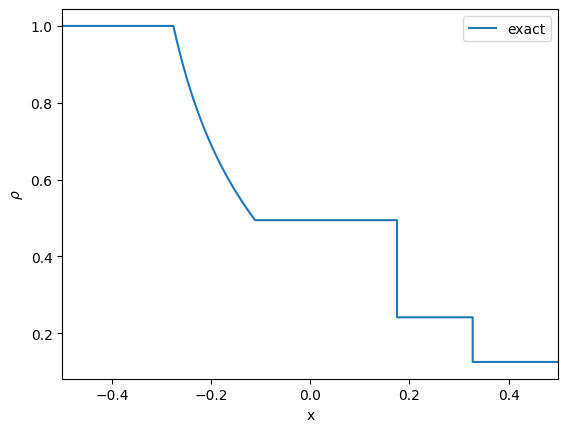

In [30]:
plt.plot(x_exact, rho_exact, label="exact")
plt.xlim(-0.5, 0.5)
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.legend()
plt.show()

## Read the Numerical Results

In [38]:
gf= SimDir("/home/lisa/simulations/Sod400/").gf
gf_800 = SimDir("/home/lisa/simulations/Sod800/").gf
print(gf_800)


Available grid data of dimension 1D (x): 
['vel[1]', 'rho', 'w_lorentz', 'tau', 'scon[2]', 'eps', 'press', 'vel[2]', 'scon[1]', 'vel[0]', 'scon[0]', 'dens']


Available grid data of dimension 1D (y): 
['press', 'vel[2]', 'tau', 'scon[0]', 'scon[1]', 'vel[1]', 'eps', 'vel[0]', 'dens', 'w_lorentz', 'rho', 'scon[2]']


Available grid data of dimension 1D (z): 
['w_lorentz', 'press', 'scon[0]', 'scon[2]', 'tau', 'rho', 'dens', 'eps', 'vel[0]', 'vel[2]', 'vel[1]', 'scon[1]']


Available grid data of dimension 2D (xy): 
[]


Available grid data of dimension 2D (xz): 
[]


Available grid data of dimension 2D (yz): 
[]


Available grid data of dimension 3D (xyz): 
[]



In [39]:
vars1d=gf.x
vars1d_800 = gf_800.x
print(vars1d_800)


Available grid data of dimension 1D (x): 
['vel[1]', 'rho', 'w_lorentz', 'tau', 'scon[2]', 'eps', 'press', 'vel[2]', 'scon[1]', 'vel[0]', 'scon[0]', 'dens']



In [40]:
rho=vars1d.fields.rho
rho_800 = vars1d_800.fields.rho

## Kuibit Standard Methods for Plots

We create a uniform grid and plot the data on it. Kuibit indeed assumes that data were produced on a grid with several meshes (AMR). In our case the grid was already uniform, so later we will see an alternative way to plot the data without interpolating them on a new grid.

In [9]:
small_grid = UniformGrid([101], x0=[-0.45], x1=[0.45])

In [53]:
print(rho.iterations)
print(rho_800.iterations)

[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200]
[0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 190, 200, 210, 220, 230, 240, 250, 260, 270, 280, 290, 300, 310, 320, 330, 340, 350, 360, 370, 380, 390, 400]


In [55]:
rho_final = rho.read_on_grid(200, small_grid)
rho_final_800 = rho_800.read_on_grid(400, small_grid)

In [56]:
print(*rho_final_800.coordinates_meshgrid())

[-4.50000000e-01 -4.41000000e-01 -4.32000000e-01 -4.23000000e-01
 -4.14000000e-01 -4.05000000e-01 -3.96000000e-01 -3.87000000e-01
 -3.78000000e-01 -3.69000000e-01 -3.60000000e-01 -3.51000000e-01
 -3.42000000e-01 -3.33000000e-01 -3.24000000e-01 -3.15000000e-01
 -3.06000000e-01 -2.97000000e-01 -2.88000000e-01 -2.79000000e-01
 -2.70000000e-01 -2.61000000e-01 -2.52000000e-01 -2.43000000e-01
 -2.34000000e-01 -2.25000000e-01 -2.16000000e-01 -2.07000000e-01
 -1.98000000e-01 -1.89000000e-01 -1.80000000e-01 -1.71000000e-01
 -1.62000000e-01 -1.53000000e-01 -1.44000000e-01 -1.35000000e-01
 -1.26000000e-01 -1.17000000e-01 -1.08000000e-01 -9.90000000e-02
 -9.00000000e-02 -8.10000000e-02 -7.20000000e-02 -6.30000000e-02
 -5.40000000e-02 -4.50000000e-02 -3.60000000e-02 -2.70000000e-02
 -1.80000000e-02 -9.00000000e-03  5.55111512e-17  9.00000000e-03
  1.80000000e-02  2.70000000e-02  3.60000000e-02  4.50000000e-02
  5.40000000e-02  6.30000000e-02  7.20000000e-02  8.10000000e-02
  9.00000000e-02  9.90000

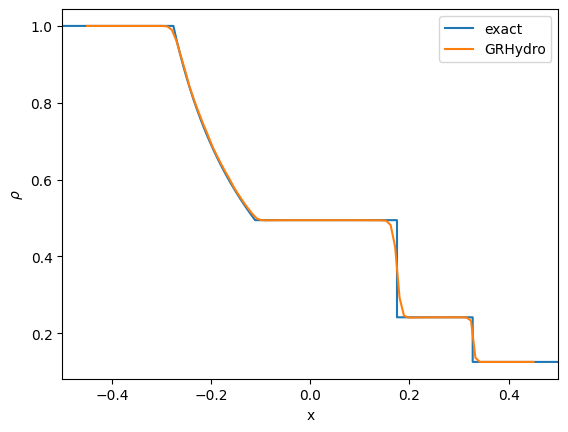

In [58]:
plt.plot(x_exact, rho_exact, label="exact")
plt.plot(*rho_final_800.coordinates_meshgrid(), rho_final_800.data_xyz, label="GRHydro")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(-0.5, 0.5)
#plt.ylim(0.1, 0.3)
plt.legend()
plt.show()

## Alternative Method
This method can only be used with simulations that used only one refinement level (i.e., a uniform grid) and using only 1 MPI process. The plot contains the real data, while using kuibit includes interpolation. Since we have only one refinement level, the two methods produce the same result.

In [41]:
#[iteration][refinement level][component number]
rho[0][0][0].data
rho_800[0][0][0].data

array([1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   , 1.   ,
       1.   , 1.   ,

In [42]:
rho_800[0][0][0].coordinates()[0].data

array([-4.98750000e-01, -4.97500000e-01, -4.96250000e-01, -4.95000000e-01,
       -4.93750000e-01, -4.92500000e-01, -4.91250000e-01, -4.90000000e-01,
       -4.88750000e-01, -4.87500000e-01, -4.86250000e-01, -4.85000000e-01,
       -4.83750000e-01, -4.82500000e-01, -4.81250000e-01, -4.80000000e-01,
       -4.78750000e-01, -4.77500000e-01, -4.76250000e-01, -4.75000000e-01,
       -4.73750000e-01, -4.72500000e-01, -4.71250000e-01, -4.70000000e-01,
       -4.68750000e-01, -4.67500000e-01, -4.66250000e-01, -4.65000000e-01,
       -4.63750000e-01, -4.62500000e-01, -4.61250000e-01, -4.60000000e-01,
       -4.58750000e-01, -4.57500000e-01, -4.56250000e-01, -4.55000000e-01,
       -4.53750000e-01, -4.52500000e-01, -4.51250000e-01, -4.50000000e-01,
       -4.48750000e-01, -4.47500000e-01, -4.46250000e-01, -4.45000000e-01,
       -4.43750000e-01, -4.42500000e-01, -4.41250000e-01, -4.40000000e-01,
       -4.38750000e-01, -4.37500000e-01, -4.36250000e-01, -4.35000000e-01,
       -4.33750000e-01, -

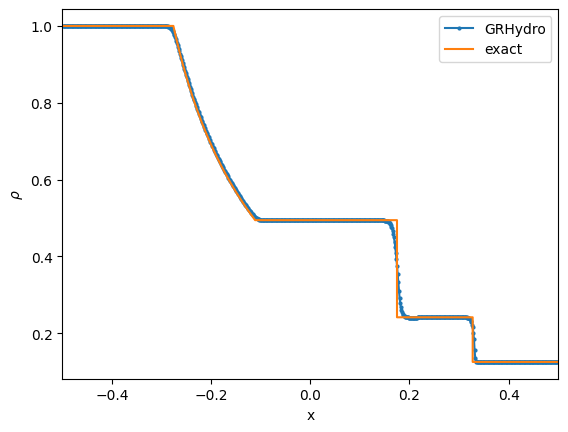

In [52]:
plt.plot(rho_800[400][0][0].coordinates()[0].data, rho_800[400][0][0].data, label="GRHydro", marker='o', markersize = 2)
plt.plot(x_exact, rho_exact, label="exact")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(-0.5, 0.5)
plt.legend()
plt.show()

## Comparing different resolutions

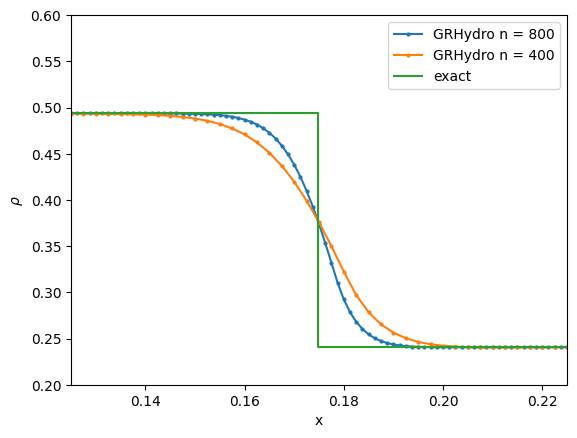

In [63]:
plt.plot(rho_800[400][0][0].coordinates()[0].data, rho_800[400][0][0].data, label="GRHydro n = 800", marker='o', markersize = 2)
plt.plot(rho[200][0][0].coordinates()[0].data, rho[200][0][0].data, label="GRHydro n = 400", marker='o', markersize = 2)
plt.plot(x_exact, rho_exact, label="exact")
plt.xlabel('x')
plt.ylabel(r'$\rho$')
plt.xlim(0.125, 0.225)
plt.ylim(0.2, 0.6)
plt.legend()
plt.show()